 # MODELLING TAIL RISK IN NEPSE USING EXTREME VALUE THEORY

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from scipy.stats import genpareto

In [38]:
from scipy.stats.mstats import winsorize

Data Prepping

In [4]:
# Importing the csv file
nepse = pd.read_csv("nepse_index_history.csv")
nepse.head()

,S.N.,Open,High,Low,Close,Change,% Change,Turnover,Date
0,1,"2,799.37","2,812.29","2,765.18","2,770.26",-26.16,-0.93,"6,531,723,226.36",2026-04-28
1,2,"2,795.74","2,806.96","2,789.22","2,796.43",7.73,0.27,"4,748,809,127.76",2026-04-27
2,3,"2,794.89","2,794.89","2,759.78","2,788.70",1.54,0.05,"5,270,399,727.63",2026-04-24
3,4,"2,806.74","2,817.10","2,779.86","2,787.15",-17.01,-0.60,"5,095,905,757.17",2026-04-23
4,5,"2,810.44","2,818.20","2,762.37","2,804.17",-2.95,-0.10,"7,813,947,342.89",2026-04-22


In [5]:
# Dropping S.N. column
nepse.drop(["S.N."], axis =1, inplace = True)

In [6]:
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date
0,"2,799.37","2,812.29","2,765.18","2,770.26",-26.16,-0.93,"6,531,723,226.36",2026-04-28
1,"2,795.74","2,806.96","2,789.22","2,796.43",7.73,0.27,"4,748,809,127.76",2026-04-27
2,"2,794.89","2,794.89","2,759.78","2,788.70",1.54,0.05,"5,270,399,727.63",2026-04-24
3,"2,806.74","2,817.10","2,779.86","2,787.15",-17.01,-0.60,"5,095,905,757.17",2026-04-23
4,"2,810.44","2,818.20","2,762.37","2,804.17",-2.95,-0.10,"7,813,947,342.89",2026-04-22


In [7]:
# Ensuring the data is datetime
nepse['Date'] = pd.to_datetime(nepse['Date'])
nepse = nepse.sort_values('Date').reset_index(drop=True)

In [13]:
numeric_cols = ['Open', 'Close', 'High', 'Low', 'Turnover']

nepse[numeric_cols] = nepse[numeric_cols].apply(
    lambda col: pd.to_numeric(
        col.astype(str)
           .str.replace(',', '', regex=False)
           .str.replace(' ', '', regex=False),
        errors='coerce'
    )
)

In [14]:
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date
0,1298.80,1300.43,1282.95,1294.39,-4.21,-0.32,573145024.0,2019-05-02
1,1293.71,1293.71,1276.73,1277.68,-16.71,-1.29,628641024.0,2019-05-05
2,1278.00,1299.41,1270.06,1299.41,21.73,1.70,619564992.0,2019-05-06
3,1298.35,1311.18,1295.73,1301.28,1.87,0.14,699849024.0,2019-05-07
4,1301.39,1304.15,1295.32,1297.60,-3.68,-0.28,494902016.0,2019-05-08


In [15]:
# Calculating log returns
nepse['log_return'] = np.log(nepse['Close'] / nepse['Close'].shift(1))
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date,log_return
0,1298.80,1300.43,1282.95,1294.39,-4.21,-0.32,573145024.0,2019-05-02,NaN
1,1293.71,1293.71,1276.73,1277.68,-16.71,-1.29,628641024.0,2019-05-05,-0.012994
2,1278.00,1299.41,1270.06,1299.41,21.73,1.70,619564992.0,2019-05-06,0.016864
3,1298.35,1311.18,1295.73,1301.28,1.87,0.14,699849024.0,2019-05-07,0.001438
4,1301.39,1304.15,1295.32,1297.60,-3.68,-0.28,494902016.0,2019-05-08,-0.002832


In [16]:
# Creating the loss series to model using EVT
nepse['loss'] = -nepse['log_return']
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date,log_return,loss
0,1298.80,1300.43,1282.95,1294.39,-4.21,-0.32,573145024.0,2019-05-02,NaN,NaN
1,1293.71,1293.71,1276.73,1277.68,-16.71,-1.29,628641024.0,2019-05-05,-0.012994,0.012994
2,1278.00,1299.41,1270.06,1299.41,21.73,1.70,619564992.0,2019-05-06,0.016864,-0.016864
3,1298.35,1311.18,1295.73,1301.28,1.87,0.14,699849024.0,2019-05-07,0.001438,-0.001438
4,1301.39,1304.15,1295.32,1297.60,-3.68,-0.28,494902016.0,2019-05-08,-0.002832,0.002832


In [17]:
# Calculating a Amihud style liquidity proxy
nepse['amihud'] = np.abs(nepse['log_return']) / nepse['Turnover']
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date,log_return,loss,amihud
0,1298.80,1300.43,1282.95,1294.39,-4.21,-0.32,573145024.0,2019-05-02,NaN,NaN,NaN
1,1293.71,1293.71,1276.73,1277.68,-16.71,-1.29,628641024.0,2019-05-05,-0.012994,0.012994,2.066936e-11
2,1278.00,1299.41,1270.06,1299.41,21.73,1.70,619564992.0,2019-05-06,0.016864,-0.016864,2.721971e-11
3,1298.35,1311.18,1295.73,1301.28,1.87,0.14,699849024.0,2019-05-07,0.001438,-0.001438,2.054843e-12
4,1301.39,1304.15,1295.32,1297.60,-3.68,-0.28,494902016.0,2019-05-08,-0.002832,0.002832,5.722327e-12


In [18]:
# High-Low Spread (Corwin-Schultz Proxy)
# This estimates the hidden cost of trading using intraday ranges
nepse['hl_ratio'] = np.log(nepse['High'] / nepse['Low'])
nepse['spread_est'] = 2 * (np.sqrt(nepse['hl_ratio']) - 1) # Simplified version
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date,log_return,loss,amihud,hl_ratio,spread_est
0,1298.80,1300.43,1282.95,1294.39,-4.21,-0.32,573145024.0,2019-05-02,NaN,NaN,NaN,0.013533,-1.767338
1,1293.71,1293.71,1276.73,1277.68,-16.71,-1.29,628641024.0,2019-05-05,-0.012994,0.012994,2.066936e-11,0.013212,-1.770114
2,1278.00,1299.41,1270.06,1299.41,21.73,1.70,619564992.0,2019-05-06,0.016864,-0.016864,2.721971e-11,0.022846,-1.697701
3,1298.35,1311.18,1295.73,1301.28,1.87,0.14,699849024.0,2019-05-07,0.001438,-0.001438,2.054843e-12,0.011853,-1.782255
4,1301.39,1304.15,1295.32,1297.60,-3.68,-0.28,494902016.0,2019-05-08,-0.002832,0.002832,5.722327e-12,0.006794,-1.835152


In [19]:
# Magnet Effect Distance
# Percentage distance from the day's Low to the Close (or Open to Close)
# If Close == Low on a crash day, the 'Magnet' pulled it to the floor.
nepse['close_at_low'] = (nepse['Close'] - nepse['Low']) / nepse['Low']
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date,log_return,loss,amihud,hl_ratio,spread_est,close_at_low
0,1298.80,1300.43,1282.95,1294.39,-4.21,-0.32,573145024.0,2019-05-02,NaN,NaN,NaN,0.013533,-1.767338,0.008917
1,1293.71,1293.71,1276.73,1277.68,-16.71,-1.29,628641024.0,2019-05-05,-0.012994,0.012994,2.066936e-11,0.013212,-1.770114,0.000744
2,1278.00,1299.41,1270.06,1299.41,21.73,1.70,619564992.0,2019-05-06,0.016864,-0.016864,2.721971e-11,0.022846,-1.697701,0.023109
3,1298.35,1311.18,1295.73,1301.28,1.87,0.14,699849024.0,2019-05-07,0.001438,-0.001438,2.054843e-12,0.011853,-1.782255,0.004283
4,1301.39,1304.15,1295.32,1297.60,-3.68,-0.28,494902016.0,2019-05-08,-0.002832,0.002832,5.722327e-12,0.006794,-1.835152,0.001760


In [20]:
# Dropping the first row with NaN values
nepse = nepse.dropna()
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date,log_return,loss,amihud,hl_ratio,spread_est,close_at_low
1,1293.71,1293.71,1276.73,1277.68,-16.71,-1.29,628641024.0,2019-05-05,-0.012994,0.012994,2.066936e-11,0.013212,-1.770114,0.000744
2,1278.00,1299.41,1270.06,1299.41,21.73,1.70,619564992.0,2019-05-06,0.016864,-0.016864,2.721971e-11,0.022846,-1.697701,0.023109
3,1298.35,1311.18,1295.73,1301.28,1.87,0.14,699849024.0,2019-05-07,0.001438,-0.001438,2.054843e-12,0.011853,-1.782255,0.004283
4,1301.39,1304.15,1295.32,1297.60,-3.68,-0.28,494902016.0,2019-05-08,-0.002832,0.002832,5.722327e-12,0.006794,-1.835152,0.001760
5,1297.57,1302.62,1290.11,1291.96,-5.64,-0.43,605086976.0,2019-05-09,-0.004356,0.004356,7.198898e-12,0.009650,-1.803530,0.001434


Selecting the threshold

C:\Users\sushi\AppData\Local\Temp\ipykernel_4808\465514389.py:11: RuntimeWarning: Mean of empty slice.
  means.append(exceedances.mean())
c:\Users\sushi\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


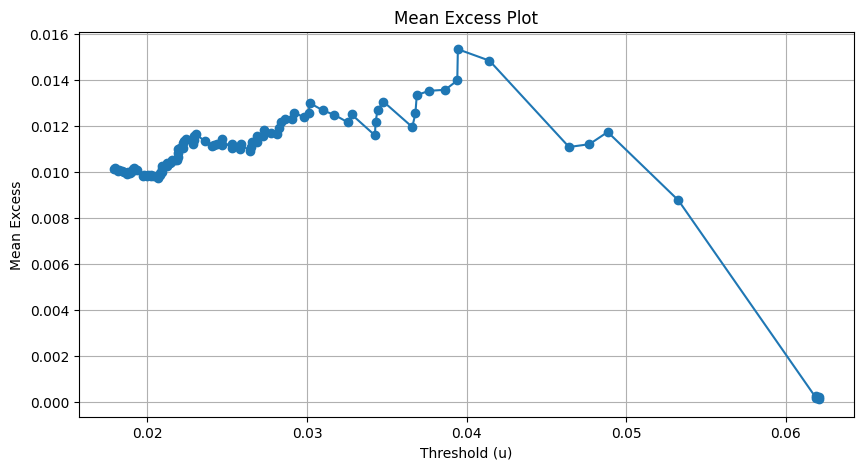

In [21]:
# We use the Mean Excess Plot to decide what constitutes as an extreme event

def plot_mean_excess(data, k=50):
    # Sort losses to evaluate different thresholds
    sorted_loss = np.sort(data)
    thresholds = sorted_loss[-k:] # Look at the top 'k' extreme values
    means = []
    
    for u in thresholds:
        exceedances = data[data > u] - u
        means.append(exceedances.mean())
        
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, means, 'o-')
    plt.title("Mean Excess Plot")
    plt.xlabel("Threshold (u)")
    plt.ylabel("Mean Excess")
    plt.grid(True)
    plt.show()

# to visually inspect where the plot becomes linear
plot_mean_excess(nepse['loss'].values, k=100)

In [ ]:
# From graph,there is s stable upward trend between u=0.20 and u=0.23, then a dip at ~0.26 and linear increment to 0.03. 
# As the threshold gets higher, there are fewer datapoints.

In [23]:
# Checking what percentile u=0.0245 is
percentile_value = (nepse['loss'] < 0.024).mean() * 100
print(f"u=0.024 is the {percentile_value:.2f}th percentile")

u=0.024 is the 96.78th percentile


Fitting the GPD

In [24]:
# We use u = [0.023, 0.024, 0.025, 0.026, 0.027] to analyze the VaR and ES for each threshold.

In [25]:
def analyze_threshold(df, u, q=0.99):
    """
    Calculates GPD parameters and risk measures for a given threshold u.
    """
    n = len(df)
    # Filter exceedances
    exceedances = df[df['loss'] > u]['loss']
    n_u = len(exceedances)
    
    # Fit GPD: y = loss - u
    y = exceedances - u
    shape, loc, scale = genpareto.fit(y, floc=0)
    
    # Calculate VaR at q level
    # Formula: u + (beta/xi) * [((n/n_u)*(1-q))^-xi - 1]
    term = (n / n_u) * (1 - q)
    var_q = u + (scale / shape) * (pow(term, -shape) - 1)
    
    # Calculate Expected Shortfall (ES)
    # Formula for xi != 0: (VaR / (1-xi)) + ((beta - xi*u) / (1-xi))
    es_q = (var_q / (1 - shape)) + ((scale - (shape * u)) / (1 - shape))
    
    return {
        "Threshold (u)": u,
        "Exceedances (n_u)": n_u,
        "Shape (xi)": shape,
        "Scale (beta)": scale,
        f"{int(q*100)}% VaR": var_q,
        f"{int(q*100)}% ES": es_q
    }

# Assuming your dataframe is named 'nepse'
thresholds = [0.023, 0.024, 0.0245, 0.025, 0.026, 0.027]
results = []

for u in thresholds:
    res = analyze_threshold(nepse, u)
    results.append(res)

# Display comparison
comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

 Threshold (u)  Exceedances (n_u)  Shape (xi)  Scale (beta)  99% VaR   99% ES
        0.0230                 53   -0.039763      0.011931 0.037077 0.048014
        0.0240                 51    0.045673      0.010417 0.036518 0.048032
        0.0245                 48    0.019324      0.010866 0.036683 0.048003
        0.0250                 46    0.024709      0.010783 0.036655 0.048007
        0.0260                 42    0.031605      0.010706 0.036610 0.048012
        0.0270                 37   -0.046932      0.012005 0.036992 0.048011


In [ ]:
# From above results, we can see that at u=0.023, xi is slightly negative. 
# At u=0.024 and higher, xi is slightly positive.
# Across the threholds, we can see that the 99% VaR and 99% ES are stable.
# We choose u=0.0245 as primary threshold as number of exceedances are nearly 50
# and VaR/ES are virtually identical to neighboring thresholds.

In [26]:
# Checking what percentile u=0.0245 is
percentile_value = (nepse['loss'] < 0.0245).mean() * 100
print(f"u=0.0245 is the {percentile_value:.1f}th percentile")

u=0.0245 is the 97.0th percentile


In [ ]:
# u=0.0245 is the 97.0th percentile which is borderline low but acceptable considering our circumstances.

In [27]:
# Test again
# Thresholds to test
u_list = [0.023, 0.024, 0.0245, 0.025, 0.026, 0.027]
n_total = len(nepse)

for u in u_list:
    # CRITICAL: Filter data for the specific threshold u
    data_above_u = nepse[nepse['loss'] > u]['loss']
    n_u = len(data_above_u)
    
    # Calculate exceedances
    y = data_above_u - u
    
    # Fit GPD
    xi, loc, beta = genpareto.fit(y, floc=0)
    
    print(f"--- Results for u = {u} ---")
    print(f"Exceedances (n_u): {n_u}")
    print(f"Shape (xi): {xi:.6f}")
    print(f"Scale (beta): {beta:.6f}\n")

--- Results for u = 0.023 ---
Exceedances (n_u): 53
Shape (xi): -0.039763
Scale (beta): 0.011931

--- Results for u = 0.024 ---
Exceedances (n_u): 51
Shape (xi): 0.045673
Scale (beta): 0.010417

--- Results for u = 0.0245 ---
Exceedances (n_u): 48
Shape (xi): 0.019324
Scale (beta): 0.010866

--- Results for u = 0.025 ---
Exceedances (n_u): 46
Shape (xi): 0.024709
Scale (beta): 0.010783

--- Results for u = 0.026 ---
Exceedances (n_u): 42
Shape (xi): 0.031605
Scale (beta): 0.010706

--- Results for u = 0.027 ---
Exceedances (n_u): 37
Shape (xi): -0.046932
Scale (beta): 0.012005



In [ ]:
# The test shows our calculations are consistent.

Implementing liquidity adjustment

In [29]:
# Using u = 0.0245
u = 0.0245
exceedances = nepse[nepse['loss'] > u]['loss']
y = exceedances - u

# Fit GPD
xi, loc, beta = genpareto.fit(y, floc=0)

# Calculate 99% VaR
n = len(nepse)
n_u = len(exceedances)
q = 0.99
var_99 = u + (beta/xi) * (((n/n_u)*(1-q))**(-xi) - 1)

In [28]:
nepse.head()

,Open,High,Low,Close,Change,% Change,Turnover,Date,log_return,loss,amihud,hl_ratio,spread_est,close_at_low
1,1293.71,1293.71,1276.73,1277.68,-16.71,-1.29,628641024.0,2019-05-05,-0.012994,0.012994,2.066936e-11,0.013212,-1.770114,0.000744
2,1278.00,1299.41,1270.06,1299.41,21.73,1.70,619564992.0,2019-05-06,0.016864,-0.016864,2.721971e-11,0.022846,-1.697701,0.023109
3,1298.35,1311.18,1295.73,1301.28,1.87,0.14,699849024.0,2019-05-07,0.001438,-0.001438,2.054843e-12,0.011853,-1.782255,0.004283
4,1301.39,1304.15,1295.32,1297.60,-3.68,-0.28,494902016.0,2019-05-08,-0.002832,0.002832,5.722327e-12,0.006794,-1.835152,0.001760
5,1297.57,1302.62,1290.11,1291.96,-5.64,-0.43,605086976.0,2019-05-09,-0.004356,0.004356,7.198898e-12,0.009650,-1.803530,0.001434


In [31]:
# Use the spread estimate volatility for the liquidity adjustment
# Using u=0.0245 from your stable results
u = 0.0245
q = 0.99
n_total = len(nepse)

# Estimate Spread using High-Low (Parkinson Proxy)
# Formula: sqrt( (1 / (4 * ln 2)) * ln(High/Low)^2 )
nepse['spread_proxy'] = np.sqrt((1 / (4 * np.log(2))) * (np.log(nepse['High'] / nepse['Low'])**2))

# --- 2. CALCULATE BASE EVT (PRICE RISK ONLY) ---
exceedances = nepse[nepse['loss'] > u]['loss']
n_u = len(exceedances)
y = exceedances - u
xi, loc, beta = genpareto.fit(y, floc=0)

# Base 99% VaR
var_99 = u + (beta / xi) * (((n_total / n_u) * (1 - q))**(-xi) - 1)
# Base 99% ES
es_99 = (var_99 / (1 - xi)) + ((beta - xi * u) / (1 - xi))

# --- 3. CALCULATE LIQUIDITY PREMIUM ---
mu_s = nepse['spread_proxy'].mean()
sigma_s = nepse['spread_proxy'].std()
k = 2.33  # 99% confidence multiplier

# Bangia adjustment (half-spread cost)
liq_premium = 0.5 * (mu_s + k * sigma_s)

# --- 4. ADJUSTED MEASURES ---
l_var_99 = var_99 + liq_premium
l_es_99 = es_99 + liq_premium

# --- 5. COMPARISON ---
print(f"{'Metric':<20} | {'Base EVT':<12} | {'Liquidity Adj':<12} | {'% Change':<10}")
print("-" * 65)
print(f"{'99% VaR':<20} | {var_99:12.6f} | {l_var_99:12.6f} | {(l_var_99/var_99-1)*100:9.2f}%")
print(f"{'99% ES':<20} | {es_99:12.6f} | {l_es_99:12.6f} | {(l_es_99/es_99-1)*100:9.2f}%")

Metric               | Base EVT     | Liquidity Adj | % Change  
-----------------------------------------------------------------
99% VaR              |     0.036683 |     0.048715 |     32.80%
99% ES               |     0.048003 |     0.060034 |     25.06%


In [35]:
nepse['amihud'] = np.abs(nepse['loss']) / nepse['Turnover']

# Use rolling or full-period mean/std of illiquidity
mu_illiq = nepse['amihud'].mean()
sigma_illiq = nepse['amihud'].std()

# Stress-test illiquidity at 99th percentile
illiq_stress = mu_illiq + k * sigma_illiq  # or just np.percentile(..., 99)

# Scale VaR by illiquidity relative to average
# Adjustment factor: how much worse is stressed illiq vs normal?
illiq_ratio = illiq_stress / mu_illiq

l_var_99_amihud = var_99 * illiq_ratio
l_es_99_amihud = es_99 * illiq_ratio

In [39]:
# Normalise Amihud by price level to get comparable scale to returns
nepse['amihud_norm'] = (np.abs(nepse['loss']) / nepse['Turnover']) * nepse['Close']

amihud_clean = winsorize(nepse['amihud_norm'].dropna(), limits=[0.01, 0.01])

# Liquidity cost = 99th percentile of normalised illiquidity
LC = np.percentile(amihud_clean, 99)

l_var_99 = var_99 + LC
l_es_99  = es_99  + LC

c:\Users\sushi\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [42]:
print(l_var_99)
print(l_es_99)
print(LC)

0.03668323547291649
0.048002936735854165
6.162844896153455e-08


In [43]:
print(nepse[['loss', 'Turnover', 'Close']].describe())
print(f"\nRaw Amihud sample: {(np.abs(nepse['loss']) / nepse['Turnover']).describe()}")
print(f"Turnover units check - median: {nepse['Turnover'].median():,.0f}")

              loss      Turnover        Close
count  1583.000000  1.583000e+03  1583.000000
mean     -0.000481  4.754458e+09  2180.859501
std       0.014240  4.434742e+09   545.506298
min      -0.058847  3.613523e+06  1109.160000
25%      -0.007038  1.340545e+09  1885.060000
50%       0.000435  3.676846e+09  2120.620000
75%       0.007282  6.676993e+09  2661.785000
max       0.062262  2.995852e+10  3198.600000

Raw Amihud sample: count    1.583000e+03
mean     9.626622e-12
std      1.432881e-10
min      0.000000e+00
25%      8.235975e-13
50%      2.280864e-12
75%      5.967915e-12
max      5.603989e-09
dtype: float64
Turnover units check - median: 3,676,846,349


In [44]:
# --- APPROACH 1: Low-turnover stress days ---
low_liq = nepse['Turnover'].quantile(0.10)
illiquid_mask = nepse['Turnover'] < low_liq

LC_stress = (nepse.loc[illiquid_mask, 'loss'] * -1).mean() - \
            (nepse['loss'] * -1).mean()

print(f"LC (stress days):  {LC_stress:.6f}")

# --- APPROACH 2: Rank-normalised Amihud ---
from scipy.stats import rankdata
nepse['turnover_rank'] = rankdata(nepse['Turnover']) / len(nepse)
nepse['amihud_norm'] = np.abs(nepse['loss']) / nepse['turnover_rank']

amihud_clean = winsorize(nepse['amihud_norm'].dropna(), limits=[0.01, 0.01])
LC_amihud = np.percentile(amihud_clean, 99) - np.mean(amihud_clean)

print(f"LC (rank-Amihud):  {LC_amihud:.6f}")

# --- COMPARE ---
for label, LC in [("Stress-day", LC_stress), ("Rank-Amihud", LC_amihud)]:
    print(f"\n[{label}]")
    print(f"  LC:       {LC:.6f}")
    print(f"  L-VaR 99: {var_99 + LC:.6f}")
    print(f"  L-ES  99: {es_99  + LC:.6f}")
    print(f"  VaR uplift: {LC / var_99 * 100:.2f}%")

LC (stress days):  0.000146
LC (rank-Amihud):  0.669844

[Stress-day]
  LC:       0.000146
  L-VaR 99: 0.036830
  L-ES  99: 0.048149
  VaR uplift: 0.40%

[Rank-Amihud]
  LC:       0.669844
  L-VaR 99: 0.706527
  L-ES  99: 0.717847
  VaR uplift: 1826.02%


c:\Users\sushi\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [45]:
# Refine: tail loss on illiquid days (instead of mean)
illiquid_losses = nepse.loc[illiquid_mask, 'loss'] * -1  # convert to losses

# 95th percentile loss on illiquid days vs overall 95th percentile
LC_refined = np.percentile(illiquid_losses, 95) - np.percentile(nepse['loss'] * -1, 95)
LC_refined = max(LC_refined, 0)  # floor at 0; liquidity shouldn't reduce risk

print(f"LC (refined):     {LC_refined:.6f}")
print(f"L-VaR 99:         {var_99 + LC_refined:.6f}")
print(f"L-ES  99:         {es_99  + LC_refined:.6f}")
print(f"VaR uplift:       {LC_refined / var_99 * 100:.2f}%")

LC (refined):     0.000000
L-VaR 99:         0.036683
L-ES  99:         0.048003
VaR uplift:       0.00%


In [46]:
for q in [0.05, 0.10, 0.20]:
    mask = nepse['Turnover'] < nepse['Turnover'].quantile(q)
    ill_losses = nepse.loc[mask, 'loss'] * -1
    lc = np.percentile(ill_losses, 95) - np.percentile(nepse['loss'] * -1, 95)
    lc = max(lc, 0)
    print(f"Threshold {int(q*100):2d}%ile | LC: {lc:.6f} | "
          f"L-VaR: {var_99+lc:.6f} | Uplift: {lc/var_99*100:.2f}%")

Threshold  5%ile | LC: 0.000000 | L-VaR: 0.036683 | Uplift: 0.00%
Threshold 10%ile | LC: 0.000000 | L-VaR: 0.036683 | Uplift: 0.00%
Threshold 20%ile | LC: 0.000000 | L-VaR: 0.036683 | Uplift: 0.00%


In [47]:
import scipy.stats as stats

# Does low turnover predict large losses?
corr, pval = stats.spearmanr(nepse['Turnover'], np.abs(nepse['loss']))
print(f"Spearman(Turnover, |loss|): {corr:.4f}, p={pval:.4f}")

# Do large loss days have lower turnover?
high_loss = nepse[np.abs(nepse['loss']) > nepse['loss'].std() * 2]
print(f"\nMean turnover on high-loss days: {high_loss['Turnover'].mean():,.0f}")
print(f"Mean turnover overall:           {nepse['Turnover'].mean():,.0f}")

Spearman(Turnover, |loss|): 0.1250, p=0.0000

Mean turnover on high-loss days: 5,905,219,780
Mean turnover overall:           4,754,457,658


In [48]:
# Estimate average days to liquidate under normal conditions
# Use: how many days does it take to turn over X% of market?
# For index-level, use autocorrelation of losses to estimate effective holding period

from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Check autocorrelation in losses
acf_vals = sm.tsa.acf(nepse['loss'].dropna(), nlags=5)
print("ACF of losses:", acf_vals)

# Effective holding period from autocorrelation
rho = acf_vals[1]
h = max(1, round(1 / (1 - abs(rho))))  # simplified estimate
print(f"Estimated holding period h: {h} days")

# Square-root-of-time scaling
l_var_99 = var_99 * np.sqrt(h)
l_es_99  = es_99  * np.sqrt(h)

print(f"\nL-VaR 99: {l_var_99:.6f}")
print(f"L-ES  99: {l_es_99:.6f}")
print(f"VaR uplift: {(np.sqrt(h)-1)*100:.2f}%")

ACF of losses: [ 1.          0.06953057 -0.04718241  0.08814762  0.04848064  0.00746219]
Estimated holding period h: 1 days

L-VaR 99: 0.036683
L-ES  99: 0.048003
VaR uplift: 0.00%
